# LVE Startup Stress Envelope: Predicting Linear Viscoelastic Limits

The **LVE envelope** gives the theoretical startup stress for a viscoelastic material
under steady shear, computed from its Prony series relaxation modulus assuming strictly
linear viscoelastic behaviour. Comparing experimental startup data with the LVE envelope
reveals nonlinear effects:

- **Strain hardening**: σ_exp > σ_LVE — common in branched polymers and associating systems
- **Strain softening**: σ_exp < σ_LVE — typical of entangled linear polymers at high Weissenberg number

**Formula:**
$$\sigma_{\text{LVE}}^+(t) = \dot{\gamma}_0 \left[ G_e t + \sum_i G_i \tau_i \left(1 - e^{-t/\tau_i}\right) \right]$$

**Learning objectives** (~20–30 min):
1. Understand the linear viscoelastic prediction for startup stress growth
2. Use `LVEEnvelope` with constructor-provided and metadata-sourced Prony parameters
3. Interpret strain hardening and softening relative to the LVE envelope
4. Visualise multi-rate envelopes on a log-log scale

In [1]:
# Colab setup — install RheoJAX if running outside a local environment
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'rheojax'], check=True)

## Setup and Imports

In [2]:
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from rheojax.core.data import RheoData
from rheojax.core.jax_config import safe_import_jax, verify_float64
from rheojax.transforms.lve_envelope import LVEEnvelope

jax, jnp = safe_import_jax()
verify_float64()
print("\u2713 JAX float64 precision enabled")

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore', message='.*non-interactive.*')

✓ JAX float64 precision enabled


## Theory

In a **startup shear flow** experiment, a constant shear rate $\dot{\gamma}_0$ is applied
at $t = 0$ to a material initially at rest. The linear (Boltzmann superposition) prediction
for the transient shear stress is:

$$\sigma^+(t) = \dot{\gamma}_0 \int_0^t G(s)\, ds$$

For a **Prony series** relaxation modulus $G(t) = G_e + \sum_i G_i e^{-t/\tau_i}$,
the integral evaluates analytically:

$$\sigma_{\text{LVE}}^+(t) = \dot{\gamma}_0 \left[ G_e t + \sum_i G_i \tau_i \left(1 - e^{-t/\tau_i}\right) \right]$$

At long times ($t \to \infty$), the stress approaches the steady-state plateau:

$$\sigma_{\text{ss}} = \dot{\gamma}_0 \left( G_e \cdot t + \sum_i G_i \tau_i \right) = \dot{\gamma}_0 \eta_0$$

where $\eta_0 = \sum_i G_i \tau_i$ is the zero-shear viscosity.

**Comparison with experimental data** reveals the nonlinear regime:
- Stress overshoot in entangled polymers occurs at $t \approx 1/\dot{\gamma}_0$ (Weissenberg units)
- The overshoot magnitude grows with $\text{Wi} = \dot{\gamma}_0 \tau_d$

## Define Material Parameters

In [3]:
# 4-mode Maxwell model (liquid-like, G_e = 0)
G_i = np.array([500.0, 1000.0, 800.0, 200.0])   # Pa
tau_i = np.array([100.0, 10.0, 1.0, 0.1])        # s
G_e = 0.0  # no equilibrium modulus

eta_0 = np.sum(G_i * tau_i)  # zero-shear viscosity

print("Material Parameters (4-mode Maxwell):")
for i in range(len(G_i)):
    print(f"  Mode {i+1}: G = {G_i[i]:.0f} Pa, \u03c4 = {tau_i[i]:.1f} s")
print(f"\nZero-shear viscosity \u03b7\u2080 = \u03a3 G\u1d62\u03c4\u1d62 = {eta_0:.0f} Pa\u00b7s")

Material Parameters (4-mode Maxwell):
  Mode 1: G = 500 Pa, τ = 100.0 s
  Mode 2: G = 1000 Pa, τ = 10.0 s
  Mode 3: G = 800 Pa, τ = 1.0 s
  Mode 4: G = 200 Pa, τ = 0.1 s

Zero-shear viscosity η₀ = Σ Gᵢτᵢ = 60820 Pa·s


## Compute LVE Envelope at Different Shear Rates

In [4]:
shear_rates = [0.01, 0.1, 1.0, 10.0]  # s^-1
envelopes = {}

for gdot in shear_rates:
    lve = LVEEnvelope(shear_rate=gdot, G_i=G_i, tau_i=tau_i, G_e=G_e)
    result_data, meta = lve.transform(None)
    lve_result = meta["lve_result"]
    envelopes[gdot] = lve_result
    print(f"  γ̇ = {gdot:.2f} s⁻¹: computed {len(lve_result.t)} time points, "
          f"σ_ss = {gdot * eta_0:.1f} Pa")

  γ̇ = 0.01 s⁻¹: computed 200 time points, σ_ss = 608.2 Pa
  γ̇ = 0.10 s⁻¹: computed 200 time points, σ_ss = 6082.0 Pa
  γ̇ = 1.00 s⁻¹: computed 200 time points, σ_ss = 60820.0 Pa
  γ̇ = 10.00 s⁻¹: computed 200 time points, σ_ss = 608200.0 Pa


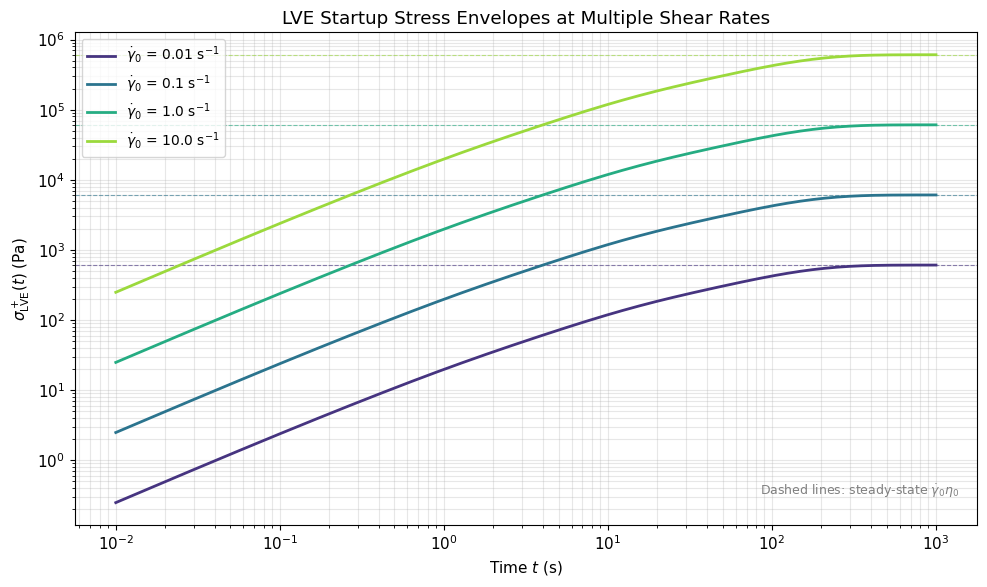

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(shear_rates)))

for gdot, color in zip(shear_rates, colors):
    res = envelopes[gdot]
    ax.loglog(
        res.t, res.sigma_lve,
        label=f"$\\dot{{\\gamma}}_0$ = {gdot} s$^{{-1}}$",
        color=color, linewidth=2.0
    )
    # Steady-state plateau
    sigma_ss = gdot * eta_0
    ax.axhline(
        sigma_ss, color=color, linestyle='--', linewidth=0.8, alpha=0.6
    )

ax.set_xlabel("Time $t$ (s)")
ax.set_ylabel("$\\sigma^+_{\\mathrm{LVE}}(t)$ (Pa)")
ax.set_title("LVE Startup Stress Envelopes at Multiple Shear Rates")
ax.legend(loc='upper left', fontsize=10)
ax.text(
    0.98, 0.05,
    "Dashed lines: steady-state $\\dot{\\gamma}_0 \\eta_0$",
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=9, color='gray'
)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Comparison with Experimental Startup Data

We now simulate an experimental dataset that exhibits a **stress overshoot** at
intermediate times — characteristic of strain hardening (e.g., branched polymer melt).
The overshoot region ($\sigma_{\text{exp}} > \sigma_{\text{LVE}}$) marks the onset of
nonlinear viscoelasticity.

In [6]:
# Simulate startup data at shear_rate = 1.0 s^-1 with a stress overshoot
shear_rate = 1.0
lve = LVEEnvelope(shear_rate=shear_rate, G_i=G_i, tau_i=tau_i, G_e=G_e)
result_data, meta = lve.transform(None)
lve_result = meta["lve_result"]

t = result_data.x
sigma_lve = result_data.y

# Simulate experimental data with strain hardening (stress overshoot)
# Peak at ~dominant relaxation time (Wi * tau_max)
t_peak = 2.0 * np.max(tau_i) / 10
sigma_exp = sigma_lve * (1.0 + 0.3 * (t / t_peak) * np.exp(1.0 - t / t_peak))
sigma_exp += 0.01 * np.max(sigma_exp) * np.random.randn(len(t))

print(f"Shear rate: {shear_rate} s⁻¹")
print(f"LVE steady-state: {shear_rate * eta_0:.1f} Pa")
print(f"Simulated overshoot peak: {np.max(sigma_exp):.1f} Pa at t = {t[np.argmax(sigma_exp)]:.2f} s")

Shear rate: 1.0 s⁻¹
LVE steady-state: 60820.0 Pa
Simulated overshoot peak: 61248.6 Pa at t = 629.50 s


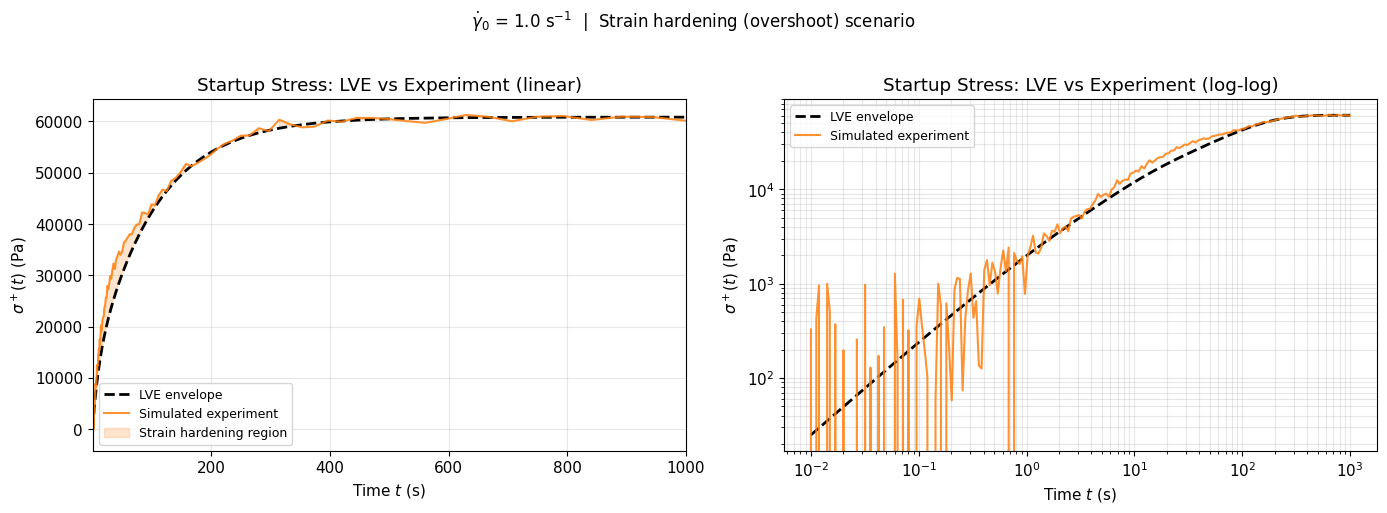

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Linear axes ---
ax = axes[0]
ax.plot(t, sigma_lve, 'k--', linewidth=2, label='LVE envelope')
ax.plot(t, sigma_exp, 'C1-', linewidth=1.5, alpha=0.85, label='Simulated experiment')

# Shade overshoot region
overshoot_mask = sigma_exp > sigma_lve
ax.fill_between(
    t, sigma_lve, sigma_exp,
    where=overshoot_mask, alpha=0.2, color='C1',
    label='Strain hardening region'
)
ax.set_xlim([t[0], min(10 * np.max(tau_i), t[-1])])
ax.set_xlabel("Time $t$ (s)")
ax.set_ylabel("$\\sigma^+(t)$ (Pa)")
ax.set_title("Startup Stress: LVE vs Experiment (linear)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Log-log axes ---
ax = axes[1]
ax.loglog(t, sigma_lve, 'k--', linewidth=2, label='LVE envelope')
ax.loglog(t, sigma_exp, 'C1-', linewidth=1.5, alpha=0.85, label='Simulated experiment')
ax.set_xlabel("Time $t$ (s)")
ax.set_ylabel("$\\sigma^+(t)$ (Pa)")
ax.set_title("Startup Stress: LVE vs Experiment (log-log)")
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

plt.suptitle(
    f"$\\dot{{\\gamma}}_0$ = {shear_rate} s$^{{-1}}$  |  Strain hardening (overshoot) scenario",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()

## Using Prony Parameters from Metadata

`LVEEnvelope` supports a data-driven workflow where Prony parameters are stored in
`RheoData.metadata` — for example, as produced by the `PronyConversion` transform.
When `G_i` and `tau_i` are omitted from the constructor, they are read automatically
from `data.metadata`.

In [8]:
# Create RheoData with Prony params embedded in metadata
data_with_prony = RheoData(
    x=np.logspace(-2, 3, 200),
    y=np.zeros(200),  # placeholder — not used by LVEEnvelope
    metadata={'G_i': G_i.tolist(), 'tau_i': tau_i.tolist(), 'G_e': G_e}
)

# No G_i / tau_i at construction — read from metadata
lve2 = LVEEnvelope(shear_rate=0.5)
result2, meta2 = lve2.transform(data_with_prony)
lve_result2 = meta2["lve_result"]

print("Parameters recovered from metadata:")
print(f"  G_i  = {lve_result2.G_i}")
print(f"  tau_i = {lve_result2.tau_i}")
print(f"  shear_rate = {lve_result2.shear_rate}")
print(f"  Output shape: t={result2.x.shape}, sigma={result2.y.shape}")

# Quick sanity check: steady-state matches eta_0 * shear_rate
expected_ss = 0.5 * eta_0
computed_ss = lve_result2.sigma_lve[-1]
print(f"\nSteady-state check: expected = {expected_ss:.1f} Pa, computed = {computed_ss:.1f} Pa")

Parameters recovered from metadata:
  G_i  = [ 500. 1000.  800.  200.]
  tau_i = [100.   10.    1.    0.1]
  shear_rate = 0.5
  Output shape: t=(200,), sigma=(200,)

Steady-state check: expected = 30410.0 Pa, computed = 30408.9 Pa


## Key Takeaways

- The **LVE envelope** is the exact linear prediction for startup stress derived analytically from the Prony series — no ODE integration needed.
- $\sigma_{\text{exp}} > \sigma_{\text{LVE}}$ indicates **strain hardening** (branched polymers, associating systems).
- $\sigma_{\text{exp}} < \sigma_{\text{LVE}}$ indicates **strain softening** (entangled linear polymers at high Weissenberg number).
- Prony parameters can be supplied via the **constructor** (`G_i`, `tau_i`) or injected through **`RheoData.metadata`** — enabling direct chaining with `PronyConversion`.
- The computation is **JIT-compiled** via JAX for fast evaluation over dense time grids, and runs identically on CPU and GPU.

## Session Information

In [9]:
import platform
import importlib.metadata

packages = ['rheojax', 'jax', 'numpy', 'matplotlib']
print(f"Python {platform.python_version()} on {platform.system()} {platform.machine()}")
print(f"JAX backend: {jax.default_backend()}")
for pkg in packages:
    try:
        ver = importlib.metadata.version(pkg)
        print(f"  {pkg}: {ver}")
    except importlib.metadata.PackageNotFoundError:
        print(f"  {pkg}: not installed")

Python 3.13.9 on Darwin arm64
JAX backend: cpu
  rheojax: 0.6.1
  jax: 0.10.0
  numpy: 2.4.5
  matplotlib: 3.10.9
